# Chi-Lambda Parameter Sweep Tutorial

This tutorial demonstrates how to use the `sweep_chi_lambda()` method to find optimal dispersive coupling (χ) and photon-cavity coupling (λ) parameters for quantum sensing experiments.

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration
)
from qsopt.core.trainable_parameters import TrainableParameters
from qsopt.core.experiment import SingleQubitExperiment, TwoQubitExperiment
from qsopt.utils.visualization import plot_chi_lambda_sweep

import warnings
warnings.filterwarnings('ignore')

## Part 1: Single-Qubit Chi-Lambda Sweep

First, let's set up a single-qubit experiment and sweep over chi and lambda parameters.

In [2]:
# Setup single-qubit experiment parameters
physical_constants = PhysicalConstants(
    n_qubits=1,
    chi=[10.0],  
    photon_cavity_coupling=10.0,
    inverse_pulse_width=1.0
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=2
)

measurement = MeasurementProtocol(
    measurement_times=[-7., 7.]
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)
noise_config = NoiseConfiguration(depolarizing=0.0, dephasing=0.0, relaxation=0.0)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

# Create trainable parameters (rotation angles)
trainable_params = TrainableParameters()
trainable_params.add_rotation_angles(
    names=["theta1", "theta2"],
    initial_values=[np.pi/2, -np.pi/2]  # Optimal rotation angles
)

# Create experiment
single_exp = SingleQubitExperiment(exp_params, trainable_params)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          1
  Cavity levels:             2
  Qubit levels:         [2]
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                  [10.0]
  Photon cavity coupling: 10.0000
  Inverse pulse width:    1.0000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-7.0, 7.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0]
  Dephasing rate:       [0.0]
  Relaxation rate:      [0.0]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


Computing χ-λ parameter sweep...
  Resolution: 10×10 = 100 points
  χ range: [1.00, 10.00] (linear scale)
  λ range: [2.00, 20.00] (linear scale)
  Progress: 10.0% | Elapsed: 10.9s
  Progress: 10.0% | Elapsed: 10.9s
  Progress: 20.0% | Elapsed: 21.0s
  Progress: 20.0% | Elapsed: 21.0s
  Progress: 30.0% | Elapsed: 31.3s
  Progress: 30.0% | Elapsed: 31.3s
  Progress: 40.0% | Elapsed: 41.5s
  Progress: 40.0% | Elapsed: 41.5s
  Progress: 50.0% | Elapsed: 52.2s
  Progress: 50.0% | Elapsed: 52.2s
  Progress: 60.0% | Elapsed: 62.7s
  Progress: 60.0% | Elapsed: 62.7s
  Progress: 70.0% | Elapsed: 73.4s
  Progress: 70.0% | Elapsed: 73.4s
  Progress: 80.0% | Elapsed: 84.2s
  Progress: 80.0% | Elapsed: 84.2s
  Progress: 90.0% | Elapsed: 94.1s
  Progress: 90.0% | Elapsed: 94.1s
  Progress: 100.0% | Elapsed: 104.9s
✓ Sweep completed in 104.9s
  Max contrast: 0.999981
  Optimal χ: 10.000
  Optimal λ: 20.000
  Progress: 100.0% | Elapsed: 104.9s
✓ Sweep completed in 104.9s
  Max contrast: 0.999981
  Op

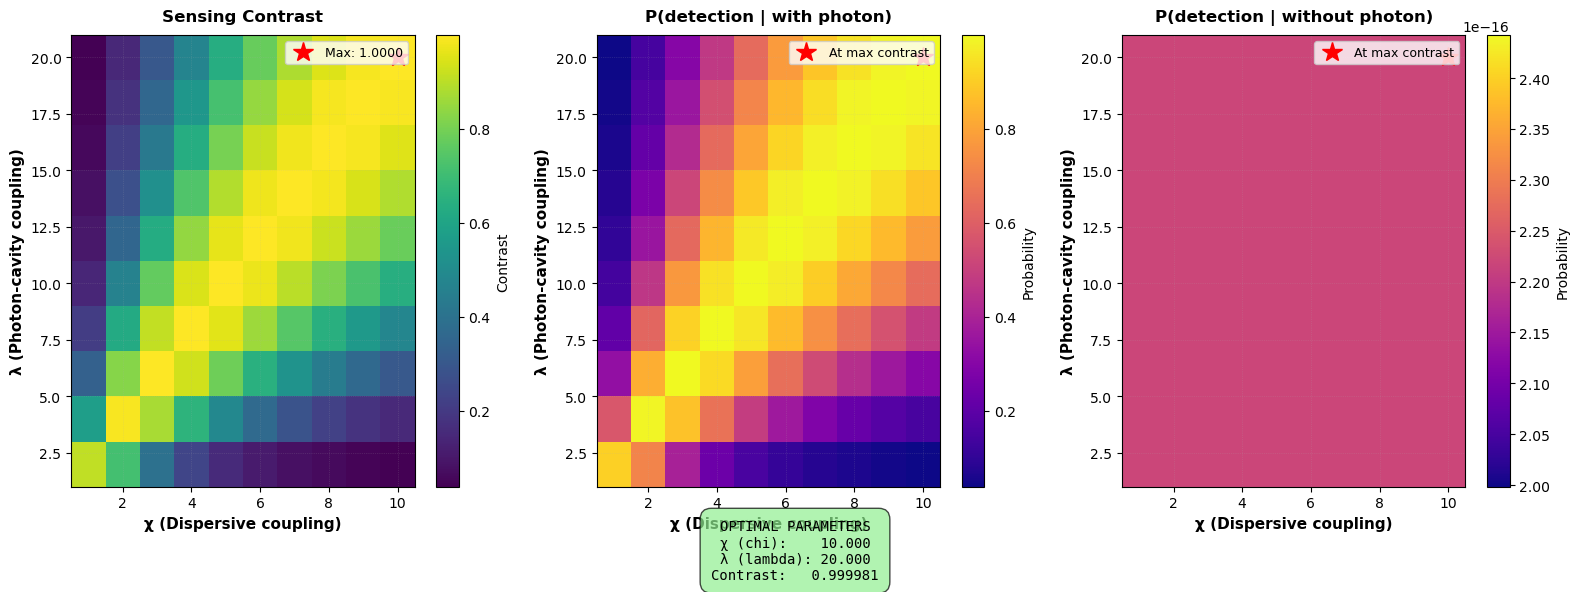

In [3]:
single_results = single_exp.sweep_chi_lambda(
    chi_interval=[1.0, 10.0],
    lambda_interval=[2.0, 20.0],
    resolution_chi=10,
    resolution_lambda=10,
    chi_scale='linear',
    lambda_scale='linear',
    batch_size=1,
    verbose=True
)

fig = plot_chi_lambda_sweep(single_results, figsize=(16, 6), save_path='sweep_1q.png')

## Part 2: Two-Qubit Chi-Lambda Sweep

Now let's perform the same sweep for a two-qubit system. Note that chi is assumed equal for both qubits (χ₁ = χ₂).

In [4]:
# Setup two-qubit experiment parameters
physical_constants_2q = PhysicalConstants(
    n_qubits=2,
    chi=[10.0, 10.0],  # Equal chi for both qubits (will be swept)
    photon_cavity_coupling=10.0,  # Will be swept
    inverse_pulse_width=1.0
)

system_dims_2q = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2, 2]
)

measurement_2q = MeasurementProtocol(
    measurement_times=[-8, 8]
)

initial_state_2q = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)
noise_config_2q = NoiseConfiguration(
    depolarizing=[0.0, 0.0],
    dephasing=[0.0, 0.0],
    relaxation=[0.0, 0.0]
)

exp_params_2q = ExperimentalParameters(
    physical_constants=physical_constants_2q,
    system_dims=system_dims_2q,
    measurement=measurement_2q,
    initial_state=initial_state_2q,
    noise_config=noise_config_2q
)

# Create trainable parameters (4 rotation angles for 2 qubits)
trainable_params_2q = TrainableParameters()
trainable_params_2q.add_rotation_angles(
    names=["theta1_q1", "theta2_q1", "theta1_q2", "theta2_q2"],
    initial_values=[np.pi/2, -np.pi/2, np.pi/2, -np.pi/2]
)

# Create two-qubit experiment
two_exp = TwoQubitExperiment(exp_params_2q, trainable_params_2q)

Computing χ-λ parameter sweep...
  Resolution: 30×30 = 900 points
  χ range: [1.00, 50.00] (linear scale)
  λ range: [1.00, 50.00] (linear scale)
  Progress: 10.0% | Elapsed: 183.0s
  Progress: 10.0% | Elapsed: 183.0s
  Progress: 20.0% | Elapsed: 1501.8s
  Progress: 20.0% | Elapsed: 1501.8s
  Progress: 30.0% | Elapsed: 1698.2s
  Progress: 30.0% | Elapsed: 1698.2s
  Progress: 40.0% | Elapsed: 1901.5s
  Progress: 40.0% | Elapsed: 1901.5s
  Progress: 50.0% | Elapsed: 2108.9s
  Progress: 50.0% | Elapsed: 2108.9s
  Progress: 60.0% | Elapsed: 2342.3s
  Progress: 60.0% | Elapsed: 2342.3s
  Progress: 70.0% | Elapsed: 2576.0s
  Progress: 70.0% | Elapsed: 2576.0s
  Progress: 80.0% | Elapsed: 2813.2s
  Progress: 80.0% | Elapsed: 2813.2s
  Progress: 90.0% | Elapsed: 3048.9s
  Progress: 90.0% | Elapsed: 3048.9s
  Progress: 100.0% | Elapsed: 3380.0s
✓ Sweep completed in 3380.0s
  Max contrast: 0.994478
  Optimal χ: 50.000
  Optimal λ: 21.276
  Progress: 100.0% | Elapsed: 3380.0s
✓ Sweep completed in

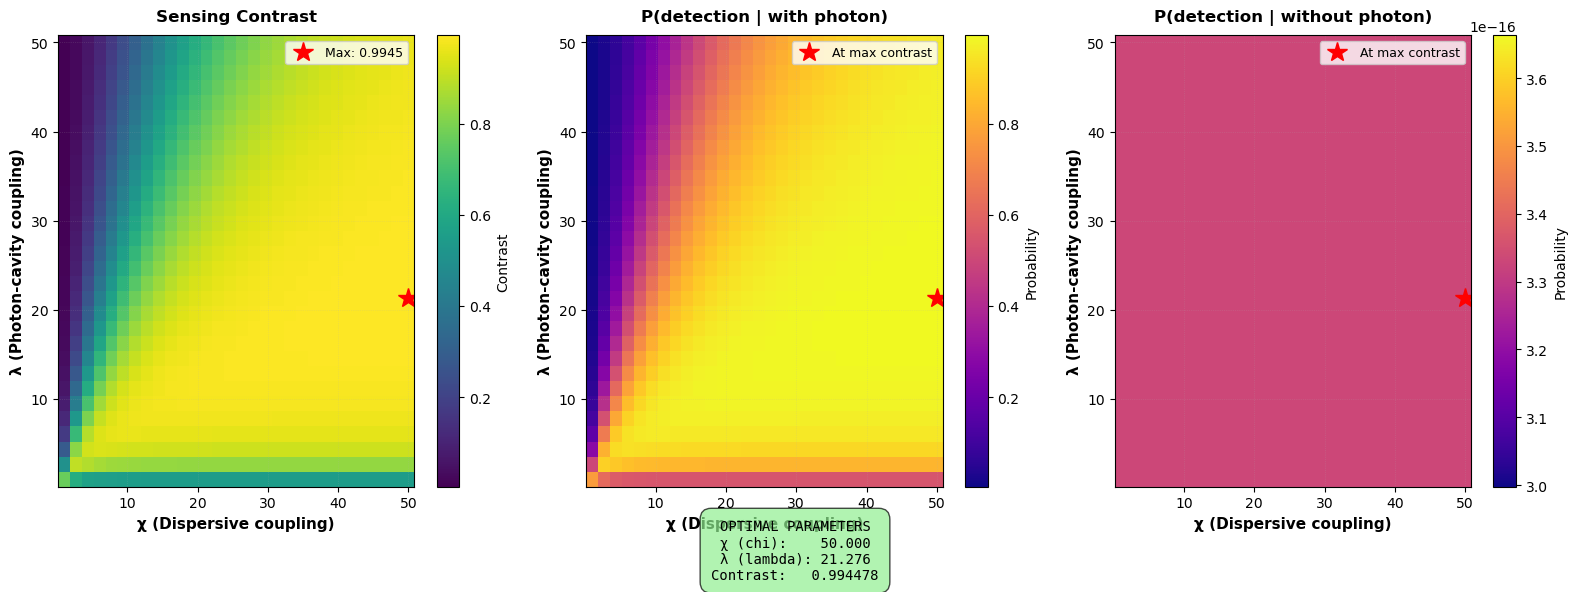

In [5]:

two_results = two_exp.sweep_chi_lambda(
    chi_interval=[1, 50],
    lambda_interval=[1, 50],
    resolution_chi=30,  # Reduced for faster computation
    resolution_lambda=30,
    chi_scale='linear',
    lambda_scale='linear',
    batch_size=1,
    verbose=True
)

fig = plot_chi_lambda_sweep(two_results, figsize=(16, 6), save_path='sweep_2q.png')

## Part 4: Selective Plot Display

The visualization function now allows you to select which plots to display using boolean parameters:
- `show_contrast`: Display sensing contrast map
- `show_detection_with`: Display detection probability with photon
- `show_detection_without`: Display detection probability without photon

The plots are arranged vertically with square aspect ratios for better readability.

In [ ]:
# Show only the contrast map
fig_contrast_only = plot_chi_lambda_sweep(
    single_results,
    show_contrast=True,
    show_detection_with=False,
    show_detection_without=False,
    save_path='sweep_contrast_only.png'
)
print("Showing only contrast map")

In [ ]:
# Show contrast and detection with photon (vertical arrangement)
fig_two_plots = plot_chi_lambda_sweep(
    single_results,
    show_contrast=True,
    show_detection_with=True,
    show_detection_without=False,
    save_path='sweep_two_plots.png'
)
print("Showing contrast and detection with photon")

In [ ]:
# You can also specify custom figure size if needed
fig_custom_size = plot_chi_lambda_sweep(
    single_results,
    show_contrast=True,
    show_detection_with=False,
    show_detection_without=False,
    figsize=(10, 8),  # Custom size instead of automatic square layout
    save_path='sweep_custom_size.png'
)
print("Custom figure size specified")